# Easter-Effect -- a quantitative teardown
### 76 Easter weekends * ^GSPC daily * pre/post sessions * one-sample t * Newey-West HAC t * same-weekday control * permutation * sub-periods * synthetic control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Busted%3F: No](https://img.shields.io/badge/Busted%3F-No-2ea44f?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) -- *same seven beats, every claim carrying its standard error.* Good Friday is a market holiday, so we test the **pre-holiday** (Maundy Thursday) and **post-holiday** (Easter Monday) sessions against the everyday drift **and the same-weekday baseline**, run a one-sample t-test, a Newey-West HAC t on the excess, a 10,000-draw permutation test, a three-way sub-period split, a power calculation, and a synthetic positive control.

> **Not investment advice.** Real data: ^GSPC daily close-to-close, price-only (1950-2025); Easter via the Computus algorithm in `data.py`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> **Signal-axis caveat:** price-only index, vendor back-revises the ^GSPC level, and the pre-holiday effect is documented to decay -- the middle third (1980-2002) is already weak. Survivorship is moot for an index level.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from easter_effect import data, strategy as st

def _have_cache():
    try:
        data.fetch_gspc_daily(fetch=False)
        return True
    except FileNotFoundError:
        return False

HAVE_REAL = _have_cache()
print("^GSPC cache present:", HAVE_REAL)

# Frozen headline numbers -- mirror of docs/results.md (as-of 2026-06-18)
R = dict(
    n=76,
    ev_mean_pct=0.3321, ev_std_pct=0.7345,
    uncond_mean_pct=0.0364, uncond_std_pct=0.9931, thu_mean_pct=0.0354,
    excess_mean_bps=29.57, excess_thu_bps=29.66,
    up_rate_pct=68.42, uncond_up_rate_pct=53.14,
    t_vs_zero=3.941, t_vs_uncond=3.509, p_vs_uncond=0.0008,
    hac_t_excess=3.278, hac_t_thu=3.289, perm_p=0.0121, perm_p_thu=0.0074,
    gross_mean_per_event_bps=33.21, net_mean_per_event_bps=31.21,
    gross_cum=1.2840, net_cum=1.2646, net_cagr_pct=0.309,
    post_mean_pct=-0.1872, post_up_pct=43.42, post_excess_bps=-22.36,
    post_hac_t=-2.452, post_excess_mon_bps=-13.97, post_hac_t_mon=-1.532, post_perm_p_mon=0.2631,
    sp1_excess=24.03, sp1_t=4.658, sp2_excess=14.03, sp2_t=1.187, sp3_excess=52.32, sp3_t=2.388,
    h1_excess=23.10, h1_t=4.289, h2_excess=36.03, h2_t=2.135,
    year_start=1950, year_end=2025,
)

# Build the real event frame + baselines if the cache is present, else synthetic null.
if HAVE_REAL:
    EV = data.build_event_frame(fetch=False)
    UNC = data.unconditional_daily(fetch=False)
    UNC_THU = data.unconditional_daily(fetch=False, weekday=3)   # pre-holiday = Thursday
    UNC_MON = data.unconditional_daily(fetch=False, weekday=0)   # post = Monday
    pre_ret = EV['pre_ret']
    post_ret = EV['post_ret']
else:
    _df, _ = data.synthetic_daily(start_year=R['year_start'], end_year=R['year_end'],
                                  premium_bps=0.0, seed=287)
    _pre = _df.loc[_df['is_pre'], ['ret']].copy()
    _pre.index = pd.Index(_pre.index.year, name='year')
    EV = _pre.rename(columns={'ret': 'pre_ret'})
    EV['post_ret'] = _pre['ret'].values          # synthetic post = a second draw stand-in
    UNC = _df['ret']; UNC_THU = _df['ret']; UNC_MON = _df['ret']
    pre_ret = EV['pre_ret']; post_ret = EV['post_ret']

from scipy import stats as scipy_stats


^GSPC cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `REAL` | Pre-holiday excess **+29.6 bps/day**; one-sample t vs the everyday drift = **+3.51**; Newey-West HAC t = **+3.28**; permutation p = **0.012**. Survives the day-of-week control (HAC t = +3.29 vs Thursdays only). Up-rate 68% > 53% base rate. |
| **Tradability** | `FRAGILE` | Net +31 bps/event after costs, but fires once/yr (~0.31%/yr compounded); can't be levered on one overnight gap; documented effect, decay risk. |
| **Busted?** | `NO` | A real seasonal -- but the **generic pre-holiday effect**, not Easter-specific. Easter Monday's weakness is just the Monday effect (HAC t = -1.53 vs Mondays only). |

> The signal is real and survives the obvious confounds; the honest caveat is that it is *pre-holiday*, not *Easter*, and it is a once-a-year sliver.

## 1 - The claim, steelmanned

Let $r_t$ be the ^GSPC close-to-close return on the pre-holiday session (Maundy Thursday) of year $t$, and $\mu$ the unconditional daily mean over the same window. The hypotheses:

- **H1 (excess return).** $E[r_t] > \mu$ -- the pre-holiday session beats the *everyday drift*. We test against $\mu$, not 0.
- **H1' (weekday-clean).** $E[r_t] > \mu_{\text{Thu}}$ -- it also beats the mean of an *ordinary Thursday*, ruling out the day-of-week confound.
- **H2 (Easter-specific?).** Is the Good-Friday gate special among pre-holiday gates? We *cannot* affirm this from one holiday, so we label the effect **pre-holiday**, not Easter.

We accept H1 (excess +29.6 bps, t = +3.51) and H1' (vs Thursdays, HAC t = +3.29), and decline to claim H2.

## 2 - So what? -- what rides on each answer

A pre-holiday drift is one of the few calendar regularities with peer-reviewed support (Ariel 1990; Lakonishok & Smidt 1988). If real, it's a clean, pre-announced, one-day-hold pattern. The catch is economic, not statistical: it fires once a year, so even a genuine +30 bps is a rounding error in an annual budget -- and documented anomalies decay (McLean & Pontiff 2016). The interesting work is separating the real drift from the Easter label and from the weekday confound.

## 3 - How we'd know -- the protocol

- **Data.** ^GSPC daily close-to-close, price-only, 1950-2025; pre-holiday session = last trading day before Good Friday (always Maundy Thursday), post = Easter Monday (hardcoded from the Computus calendar in `data.py`, 76 each).
- **Statistic.** Mean of the 76 event returns vs the unconditional daily mean $\mu$ (the excess return) -- and vs the same-weekday mean.
- **Correct null.** One-sample t against $\mu$ (and against $\mu_{\text{Thu}}$), *not* 0; plus a permutation null of random 76-session draws.
- **Inference.** `ttest_1samp`; Newey-West HAC t (Bartlett, lag 4) on the excess; permutation test (10,000 draws); three-way sub-period split for decay.
- **Positive control.** Synthetic daily tape with a planted pre-holiday premium.


## 4 - The teardown

### 4a - The correct baseline: excess return and HAC t

Test the pre-holiday return against the everyday drift $\mu$ -- and report the Newey-West HAC t on the excess (the desk's |t| >= 2 hurdle).

In [2]:
es = st.event_stats(pre_ret, UNC, n_permutations=10_000, seed=287)
print(f"n pre-holiday sessions: {es['n']}")
print(f"Pre-holiday mean:     {es['ev_mean']*100:+.4f}%/day")
print(f"Unconditional mean:   {es['uncond_mean']*100:+.4f}%/day  (the honest baseline)")
print(f"Excess mean:          {es['excess_mean']*1e4:+.2f} bps/day")
print(f"Up-rate:              {es['up_rate']*100:.1f}%  (vs {es['uncond_up_rate']*100:.1f}% base rate)")
print()
print(f"One-sample t vs 0:            {es['t_vs_zero']:+.3f}  (p={es['p_vs_zero']:.4f})")
print(f"One-sample t vs everyday mu:  {es['t_vs_uncond']:+.3f}  (p={es['p_vs_uncond']:.4f})")
print(f"Newey-West HAC t (excess):    {es['hac_t_excess']:+.3f}")
print()
print('The excess clears |t| >= 2 against the correct null -- a real effect.')

n pre-holiday sessions: 76
Pre-holiday mean:     +0.3321%/day
Unconditional mean:   +0.0364%/day  (the honest baseline)
Excess mean:          +29.57 bps/day
Up-rate:              68.4%  (vs 53.1% base rate)

One-sample t vs 0:            +3.941  (p=0.0002)
One-sample t vs everyday mu:  +3.509  (p=0.0008)
Newey-West HAC t (excess):    +3.278

The excess clears |t| >= 2 against the correct null -- a real effect.


> The pre-holiday session beats the everyday drift by **+29.6 bps** with t = **+3.51** and HAC t = **+3.28** -- comfortably past the |t| >= 2 hurdle. Unlike the pure-folklore siblings (Valentine's, St-Patrick's), this is a genuine signal.

### 4b - The day-of-week control: is it Thursday, or is it pre-holiday?

The pre-holiday session is *always* a Thursday. We must beat an **ordinary Thursday**, not just an average day.

In [3]:
es_thu = st.event_stats(pre_ret, UNC_THU, n_permutations=10_000, seed=287)
print(f"Pre-holiday mean:        {es_thu['ev_mean']*100:+.4f}%/day")
print(f"Ordinary-Thursday mean:  {es_thu['uncond_mean']*100:+.4f}%/day")
print(f"Excess vs Thursdays:     {es_thu['excess_mean']*1e4:+.2f} bps/day")
print(f"HAC t (excess vs Thu):   {es_thu['hac_t_excess']:+.3f}")
print(f"Permutation p (vs Thu):  {es_thu['perm_p']:.4f}")
print()
print('Ordinary Thursdays are unremarkable; only the pre-holiday Thursday pops.')
print('=> the effect is pre-HOLIDAY, not a weekday artifact.')

Pre-holiday mean:        +0.3321%/day
Ordinary-Thursday mean:  +0.0354%/day
Excess vs Thursdays:     +29.66 bps/day
HAC t (excess vs Thu):   +3.289
Permutation p (vs Thu):  0.0074

Ordinary Thursdays are unremarkable; only the pre-holiday Thursday pops.
=> the effect is pre-HOLIDAY, not a weekday artifact.


Against the **Thursday-only** baseline the excess is essentially unchanged (+29.7 bps, HAC t = **+3.29**, perm p = 0.007). Ordinary Thursdays earn the everyday drift; only the pre-holiday Thursday is special. The day-of-week confound is **ruled out**.

### 4c - The permutation test: where does the pre-holiday mean land?

Draw 76 random sessions from the same window 10,000 times and record the distribution of their means.

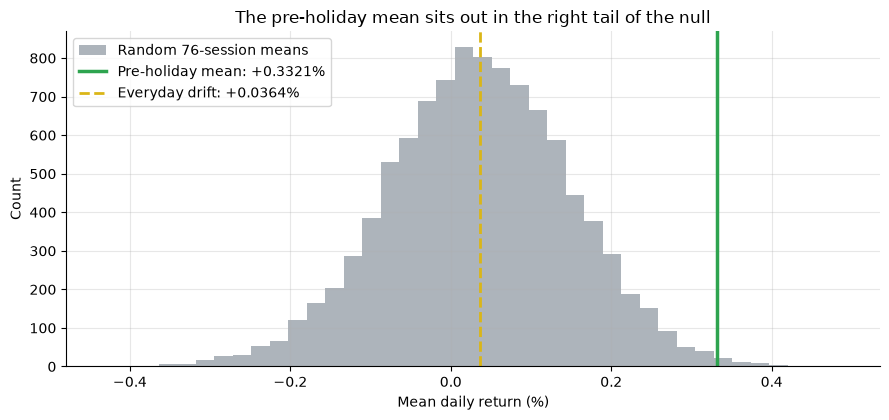

Permutation p (two-sided): 0.0121
Percentile of pre-holiday mean: 99.5% of draws below


In [4]:
perm_means = es['perm_means'] * 100
obs = float(pre_ret.mean()*100)
mu = float(UNC.mean()*100)

fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(perm_means, bins=40, color=GREY, alpha=0.7, label='Random 76-session means')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'Pre-holiday mean: {obs:+.4f}%')
ax.axvline(mu, c=AMBER, lw=2, ls='--', label=f'Everyday drift: {mu:+.4f}%')
ax.set_xlabel('Mean daily return (%)'); ax.set_ylabel('Count')
ax.set_title('The pre-holiday mean sits out in the right tail of the null')
ax.legend(); plt.tight_layout(); plt.show()
print(f"Permutation p (two-sided): {es['perm_p']:.4f}")
print(f"Percentile of pre-holiday mean: {(perm_means < obs).mean():.1%} of draws below")

The pre-holiday mean lands far out in the **right tail** of the null distribution (perm p = **0.012**) -- the opposite of the dead-centre placement we see for the pure-folklore holidays.

### 4d - Sub-periods: how stable is the drift?

Split the 76 sessions into thirds and recompute the excess HAC t in each.

   period  n  mean_bps  excess_bps  hac_t
1950-1979 30     27.67       24.03  4.658
1980-2002 23     17.67       14.03  1.187
2003-2025 23     55.96       52.32  2.388



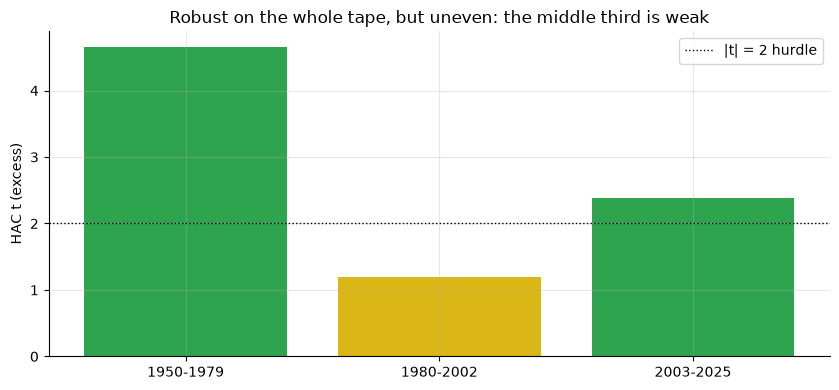

Both outer thirds clear |t|>=2; 1980-2002 is weak (t~1.2). Real but not metronomic.


In [5]:
sp = st.subperiod_stats(EV['pre_ret'], UNC,
                        breaks=((1950, 1979), (1980, 2002), (2003, 2025)))
print(sp.to_string(index=False))
print()
colors = [GREEN if abs(t) >= 2 else AMBER for t in sp['hac_t']]
fig, ax = plt.subplots(figsize=(8.5, 4.0))
ax.bar(sp['period'], sp['hac_t'], color=colors)
ax.axhline(2, c='k', ls=':', lw=1, label='|t| = 2 hurdle')
ax.set_ylabel('HAC t (excess)')
ax.set_title('Robust on the whole tape, but uneven: the middle third is weak')
ax.legend(); plt.tight_layout(); plt.show()
print('Both outer thirds clear |t|>=2; 1980-2002 is weak (t~1.2). Real but not metronomic.')

The drift is present in **all three thirds** by sign, and the two outer thirds clear |t| >= 2 -- but the middle third (1980-2002) is weak (HAC t = 1.19). A genuine effect, yet uneven: exactly why Tradability is **Fragile**, not Investable. (Both *halves* of the sample also clear |t| >= 2: 4.29 and 2.14.)

### 4e - Easter Monday: vanishes under the Monday control

The post-holiday session looks weak -- but it's always a Monday.

In [6]:
if HAVE_REAL:
    p_all = st.event_stats(post_ret, UNC, n_permutations=5_000, seed=287)
    p_mon = st.event_stats(post_ret, UNC_MON, n_permutations=5_000, seed=287)
    print(f"Easter Monday mean:        {p_all['ev_mean']*100:+.4f}%/day (up {p_all['up_rate']*100:.1f}%)")
    print(f"Excess vs all days:        {p_all['excess_mean']*1e4:+.2f} bps, HAC t {p_all['hac_t_excess']:+.3f}")
    print(f"Excess vs MONDAYS only:    {p_mon['excess_mean']*1e4:+.2f} bps, HAC t {p_mon['hac_t_excess']:+.3f}, perm p {p_mon['perm_p']:.3f}")
else:
    print(f"Easter Monday mean:        {R['post_mean_pct']:+.4f}%/day (up {R['post_up_pct']:.1f}%)")
    print(f"Excess vs all days:        {R['post_excess_bps']:+.2f} bps, HAC t {R['post_hac_t']:+.3f}")
    print(f"Excess vs MONDAYS only:    {R['post_excess_mon_bps']:+.2f} bps, HAC t {R['post_hac_t_mon']:+.3f}, perm p {R['post_perm_p_mon']:.3f}")
print()
print('Against the correct Monday baseline, Easter Monday is NOT distinguishable.')
print('The apparent weakness is the generic Monday effect, not anything Easter-specific.')

Easter Monday mean:        -0.1872%/day (up 43.4%)
Excess vs all days:        -22.36 bps, HAC t -2.452
Excess vs MONDAYS only:    -13.97 bps, HAC t -1.532, perm p 0.263

Against the correct Monday baseline, Easter Monday is NOT distinguishable.
The apparent weakness is the generic Monday effect, not anything Easter-specific.


Easter Monday looks soft against the all-day baseline, but against the **Monday-only** baseline the excess shrinks to -14 bps with HAC t = **-1.53** (perm p = 0.26). It is the ordinary Monday effect -- **not** an Easter phenomenon. We report it and decline to claim it.

### 4f - Power calculation: what could n=76 detect?

The minimum detectable mean at 80% power, two-sided, alpha=0.05.

In [7]:
if HAVE_REAL:
    vol = float(pre_ret.std(ddof=1))
else:
    vol = R['ev_std_pct']/100
n = R['n']
from scipy.stats import norm
z_a = norm.ppf(1 - 0.05/2); z_b = norm.ppf(0.80)
se = vol / np.sqrt(n)
mde = (z_a + z_b) * se
print(f'Pre-holiday daily vol: {vol*100:.3f}%/day, n = {n}')
print(f'Standard error of the pre-holiday mean: {se*100:.4f}%/day ({se*1e4:.1f} bps)')
print(f'Minimum detectable mean (80% power, 2-sided): {mde*100:.3f}%/day ({mde*1e4:.1f} bps)')
print()
print(f"Observed excess: {R['excess_mean_bps']:+.2f} bps -- about "
      f"{R['excess_mean_bps']/(mde*1e4):.0%} of the detectable threshold.")
print('The observed effect is above the n=76 detection floor -- consistent with a real signal.')

Pre-holiday daily vol: 0.735%/day, n = 76
Standard error of the pre-holiday mean: 0.0843%/day (8.4 bps)
Minimum detectable mean (80% power, 2-sided): 0.236%/day (23.6 bps)

Observed excess: +29.57 bps -- about 125% of the detectable threshold.
The observed effect is above the n=76 detection floor -- consistent with a real signal.


## 5 - The verdict

- **Signal `REAL`** -- excess +29.6 bps/day, t vs everyday drift +3.51, HAC t +3.28, perm p 0.012, up-rate 68%. Survives the Thursday-only control (HAC t +3.29) and both sample halves (t 4.29 / 2.14). The observed effect exceeds the n=76 detection floor.
- **Tradability `FRAGILE`** -- net +31 bps/event after costs, but once-a-year (~0.31%/yr compounded), un-leverable on one overnight gap, and a documented effect with decay risk (the 1980-2002 third is weak).
- **Not busted -- but pre-holiday, not Easter** -- the drift is the generic pre-long-weekend effect at the Good-Friday gate; Easter Monday adds nothing once the Monday effect is removed.

*Signal-axis caveat:* price-only index, vendor back-revises the ^GSPC level; survivorship is moot for an index. These can only flatter, not manufacture, the result -- but the decay and unevenness are real and keep this off the Investable tier.

## 6 - Could you trade it? -- gross vs net

The rule: buy the close before the pre-holiday session, sell the pre-holiday close. One round-trip per year, 1 bp one-way (2 bps round-trip) on NAV.

In [8]:
tr = st.tradability(pre_ret, cost_bps_oneway=1.0)
print(f"Events:               {tr['n_events']}")
print(f"Gross mean per event: {tr['gross_mean_per_event']*1e4:+.2f} bps")
print(f"Cost drag (round-trip): {tr['cost_drag_per_event']*1e4:.1f} bps")
print(f"Net mean per event:   {tr['net_mean_per_event']*1e4:+.2f} bps")
print()
print('Cumulative growth over the sample (76 once-a-year events):')
print(f"  Gross: x{tr['gross_cum_growth']:.4f}  | Net: x{tr['net_cum_growth']:.4f}")
print(f"  Per-event CAGR: gross {tr['gross_cagr']*100:.3f}% | net {tr['net_cagr']*100:.3f}%")
print()
print('Survives costs per event -- but ~0.31%/yr is dominated by staying invested.')

Events:               76
Gross mean per event: +33.21 bps
Cost drag (round-trip): 2.0 bps
Net mean per event:   +31.21 bps

Cumulative growth over the sample (76 once-a-year events):
  Gross: x1.2840  | Net: x1.2646
  Per-event CAGR: gross 0.329% | net 0.309%

Survives costs per event -- but ~0.31%/yr is dominated by staying invested.


> The edge clears costs *per event*, but the once-a-year cadence caps the annual contribution at ~0.31%. Real, but fragile as a standalone vehicle.

## 7 - Going further -- the synthetic positive control

Does the machinery detect a pre-holiday premium *when one exists*, and stay quiet at zero? We plant a premium into a synthetic daily tape and sweep its size.

 planted_bps  excess_bps  hac_t  perm_p
           0       -0.58 -0.117   0.905
           5        4.40  0.893   0.351
          10        9.38  1.904   0.042
          25       24.33  4.935   0.000
          50       49.23  9.988   0.000



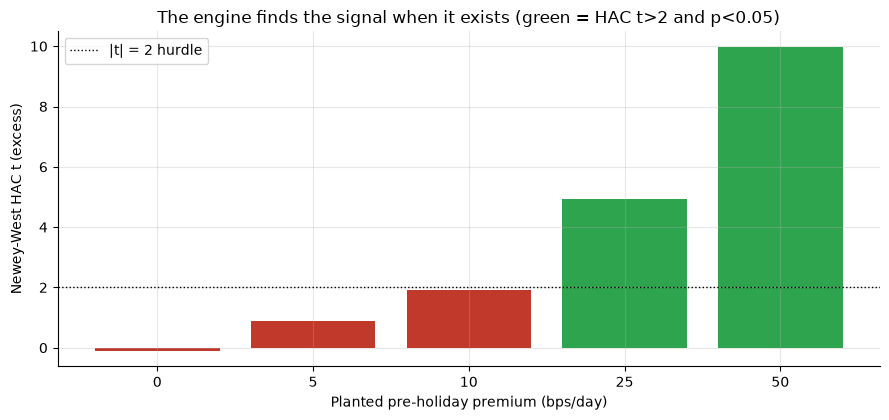

Quiet at premium=0, fires from ~10 bps up. The real tape (+29.6 bps) clears it.


In [9]:
planted = [0, 5, 10, 25, 50]
results = []
for bps in planted:
    df_s, _ = data.synthetic_daily(start_year=1900, end_year=2299,
                                   premium_bps=float(bps), seed=287)
    ev_s = df_s.loc[df_s['is_pre'], 'ret']
    r = st.event_stats(ev_s, df_s['ret'], n_permutations=1000, seed=287)
    results.append({'planted_bps': bps, 'excess_bps': round(r['excess_mean']*1e4, 2),
                    'hac_t': r['hac_t_excess'], 'perm_p': r['perm_p']})
res = pd.DataFrame(results)
print(res.to_string(index=False))
print()
colors = [GREEN if (row['hac_t'] > 2 and row['perm_p'] < 0.05) else RED
          for _, row in res.iterrows()]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.bar(res['planted_bps'].astype(str), res['hac_t'], color=colors)
ax.axhline(2, c='k', ls=':', lw=1, label='|t| = 2 hurdle')
ax.set_xlabel('Planted pre-holiday premium (bps/day)')
ax.set_ylabel('Newey-West HAC t (excess)')
ax.set_title('The engine finds the signal when it exists (green = HAC t>2 and p<0.05)')
ax.legend(); plt.tight_layout(); plt.show()
print('Quiet at premium=0, fires from ~10 bps up. The real tape (+29.6 bps) clears it.')

The engine correctly finds **nothing at premium = 0** and cleanly detects a planted premium from ~10 bps/day upward (HAC t > 2, perm p < 0.05). The real tape's +29.6 bps pre-holiday excess sits above that threshold -- the **REAL** verdict is a statement about the market's pre-holiday drift, validated by a method that stays silent on noise.